<a href="https://githubtocolab.com/gee-community/geemap/blob/master/docs/notebooks/12_zonal_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

Uncomment the following line to install [geemap](https://geemap.org) if needed.

In [ ]:
#last edited 6/11
!pip install geemap
!pip install cartopy scipy
!pip install pycrs
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 50.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycrs: filename=PyCRS-1.0.2-py3-none-any.whl size=32686 sha256=3a569687eafdc524f99018bdd709f4e6208b17ba6e0c205cbde06c10393e93fe
  Stored in directory: /root/.cache/pip/wheels/b5/4a/72/1ba05f57ddf2cc80ad21a26512097762561d646ff3ff85f729
Successfully built pycrs


In [ ]:
import geemap
import ee
import pycrs
import geopandas as gpd
import cartopy
import glob
import pandas as pd
ee.Authenticate()
ee.Initialize(project="waterbalance-496019")

print(geemap.__version__
      )

0.37.3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#dictionary of variables [feature collection, precip band, pix]

## edit dictionary
variable_dict  = {
    'gridmet':['IDAHO_EPSCOR/GRIDMET','pr',4638.3],
    'chirps':['UCSB-CHG/CHIRPS/DAILY','precipitation',5566],
    'prism':['projects/sat-io/open-datasets/OREGONSTATE/PRISM_800_DAILY', 'ppt',800],
    'nclimgrid':['projects/climate-engine-pro/assets/noaa-ncei-nclimgrid/daily', 'precip',4630],
    'nldas-2':['NASA/NLDAS/FORA0125_H002','total_precipitation',13915],
    'AgEra-5':['projects/climate-engine-pro/assets/ce-ag-era5-v2/daily','Precipitation_Flux',9600],
    'rdpa':['projects/climate-engine-pro/assets/ce-rdpa-daily','precip',10000]
}

In [ ]:
# Earth Engine Water Boundary Dataset
target_hucs = ["15010005"] # Define multiple target HUCs

def get_multiple_hucs(huc_list):
    # Load the USGS HUC08 dataset
    huc_collection = ee.FeatureCollection("USGS/WBD/2017/HUC08")

    # Filter for all HUCs present in your input list
    filtered_hucs = huc_collection.filter(ee.Filter.inList("huc8", huc_list))
    return filtered_hucs

basin = get_multiple_hucs(target_hucs) # Use the function to get a FeatureCollection of multiple HUCs

# Set visualization parameters.
HUC_vis = {
    'color': '0000FFFF',
    'width': 1,
    'lineType': 'solid',
    'fillColor': '000000'
}



In [ ]:
## function to select the precip dataset and start and end date

#==============================
## CHOOSE DATASET TO TEST HERE
#==============================
dataset_i = 'AgEra-5'

def select_precip_data(dataset_name, start_date, end_date):

  image_col_i = variable_dict[dataset_name][0]
  band_i = variable_dict[dataset_name][1]
  scale_i = variable_dict[dataset_name][2]

  # assign the selected image collection to a variable
  selected_imgcol = ee.ImageCollection(image_col_i).filter(
      ee.Filter.date(start_date, end_date)
  )

  precip_collection = selected_imgcol.select(band_i)

  return precip_collection, scale_i, band_i


# This is the function to reduce the image collection and return a single image that can be clipped

def reduce_precip_image(image_collection):
  # Reduce the ImageCollection to a single Image (e.g., sum of precipitation)
  precip_image = image_collection.sum()

  #return the reduced image so it can be clipped later for the map
  return precip_image


precip_vis = {
    'min': 0,
    'max': 100,
    'palette': ['d8d8d8', '4addff', '5affa3', 'f2ff89', 'ff725c'],
}

# Add the original sum precipitation image
#Map.add_layer(precip_image, precip_vis, 'Sum Precipitation')

# View selected basin(s)
Map= geemap.Map(center = (39.833,-98.583), zoom = 4)
Map.add_layer(basin, HUC_vis, "Selected basin")
Map


Map(center=[39.833, -98.583], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…

In [ ]:


#unpack the return values into three variables
#then run reduce_precip_image

#==================
# Select Dates Here
#==================
collection, scale, band = select_precip_data(dataset_i, '2020-10-01', '2024-10-01')
precip_image = reduce_precip_image(collection)

## Clip the sum precipitation data to the Lake Mead HUC boundary
clipped_precip = precip_image.clip(basin)
Map.add_layer(clipped_precip, precip_vis, 'Clipped Sum Precipitation')


In [ ]:
# Function to calculate the daily average over the basin area
def calculate_daily_stats(img_col, img_scale, img_band):

  def process_single_image(img):

      # Calculate spatial mean for this specific day
      stats = img.reduceRegion(
          reducer=ee.Reducer.mean(),
          geometry=basin,
          scale=img_scale,  # GridMET native resolution is ~4000m (4-km)
          maxPixels=1e9
      )

      #Extract the system date string (YYYY-MM-DD)
      date_string = img.date().format('yyyy-MM-dd')

      # Create a unique column name for this dataset
      column_name = f"precipitation_mm"

      return ee.Feature(None, {
            'date': date_string,
            column_name: stats.get(img_band) # Map to the unique column name
        })

  #map the single image process across the collection and return
  return ee.FeatureCollection(img_col.map(process_single_image))

In [ ]:
## Testing calculation with multiple datasets

#call the function

#the calculation function over the entire daily collection
daily_features = calculate_daily_stats(collection, scale, band)

##Convert the Earth Engine FeatureCollection to a local Pandas DataFrame
df_collection = geemap.ee_to_df(ee.FeatureCollection(daily_features))

## Standardize dates, sort chronologically, and export each CSV independently
datasets = {
    dataset_i : df_collection
}

for name, df_item in datasets.items(): # Changed 'df' to 'df_item' to avoid conflict with pd.read_csv df
    if 'date' in df_item.columns and 'precipitation_mm' in df_item.columns:
        # Enforce clean Pandas datetime format
        df_item['date'] = pd.to_datetime(df_item['date'], errors='coerce').dt.strftime('%Y-%m-%d')

        # Sort chronologically by date
        df_item = df_item.sort_values('date')

        # FORCE COLUMN ORDER: Put 'date' first, then 'precipitation_mm'
        df_item = df_item[['date', 'precipitation_mm']]

        # Clean up index
        df_item = df_item.reset_index(drop=True)

        # Save as a completely independent file
        file_path = f'{name}_daily_precipitation.csv'
        df_item.to_csv(file_path, index=False)

        print(f"--- Finished exporting {file_path} ---")
        print(df_item.head(), "\n")


--- Finished exporting AgEra-5_daily_precipitation.csv ---
         date  precipitation_mm
0  2020-10-01               0.0
1  2020-10-02               0.0
2  2020-10-03               0.0
3  2020-10-04               0.0
4  2020-10-05               0.0 



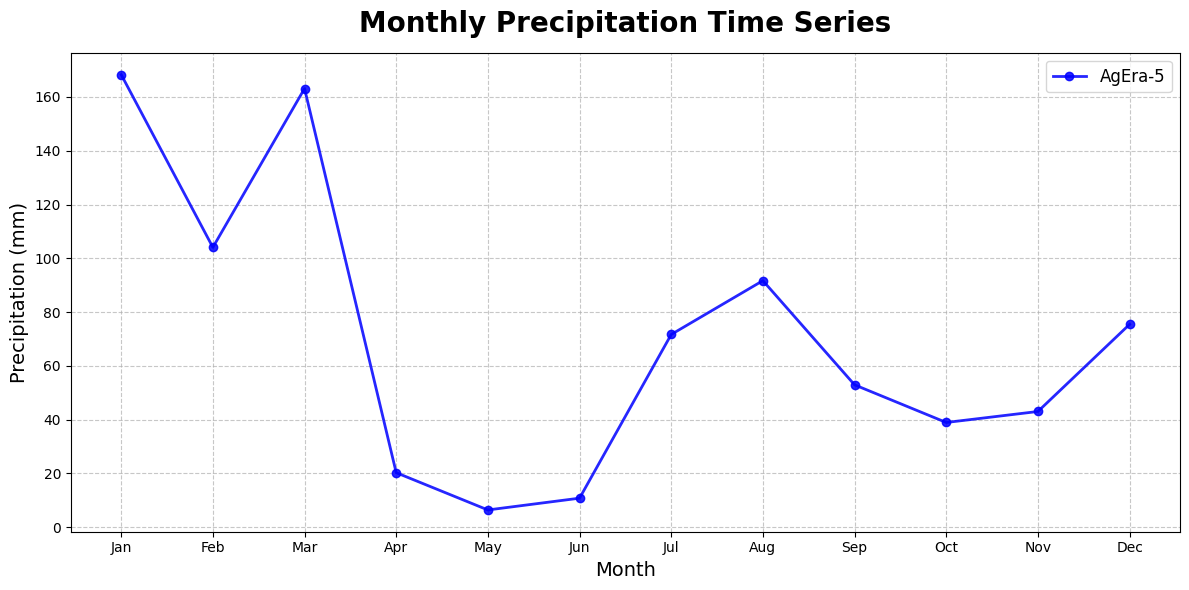

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import json
import pandas as pd # Ensure pandas is imported if not already

# import the cartoee functionality from geemap
from geemap import cartoee

# Initialize lists to hold the monthly aggregated data for plotting
monthly_plots = []

# Define configurations for each dataset variable, label, and plot color
configs = [
    (df_collection, dataset_i, 'blue'),
]

# Loop through each dataset to clean dates and aggregate by month
for df, label, color in configs:
    if 'date' in df.columns:
        # Convert to true datetime objects so we can extract month components
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df.sort_values('date', inplace=True)

        # Dynamically grab the exact precipitation column name (handles 'precipitation_mm' or custom naming)
        precip_col = [col for col in df.columns if 'precip' in col.lower()][0]

        # Extract month name for plotting and month number for sorting
        df['month_name'] = df['date'].dt.strftime('%b') # Abbreviated month name (Jan, Feb, etc.)
        df['month_num'] = df['date'].dt.month           # Numeric month for sorting

        # Aggregate precipitation by month using the dynamic column name
        monthly_precipitation = df.groupby(['month_num', 'month_name'])[precip_col].sum().reset_index()

        # Sort by month number to ensure chronological order
        monthly_precipitation = monthly_precipitation.sort_values('month_num').reset_index(drop=True)

        # Store for the plotting step
        monthly_plots.append((monthly_precipitation, precip_col, label, color))

# Initialize the multi-line chart (using your preferred 12x6 dimensions)
plt.figure(figsize=(12, 6))

# Plot each aggregated dataset layer directly
for monthly_df, precip_col, label, color in monthly_plots:
    plt.plot(
        monthly_df['month_name'],
        monthly_df[precip_col],
        color=color,
        linewidth=2,
        marker='o',  # Added marker for clarity
        label=label,
        alpha=0.85
    )

# Apply your preferred formatting parameters
plt.title('Monthly Precipitation Time Series', fontsize=20, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Precipitation (mm)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Render the legend
plt.legend(fontsize=12, loc='upper right')

# Output to screen
plt.tight_layout()
plt.show()